## Inmatning och en överskådligblick av vårt dataset

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#importerar housing
df = pd.read_csv('housing.csv')
print ("Hus")

Hus


Vi importerar vår dataset "Housing". 
Vi vet att det handlar om huspriser som är insamlat någon gång under 90-talet i Kalifornien, USA. 

In [5]:
# Vi börjar med aytt utforska datan. (df.shape och df.types för datatyper, men kommandot df.info ger både och)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


*Vi har 10 variabler varav 9 är kontunerliga numeriska och en kategorisk variabel.
* Vi har 20640 st observationer
* Variabel nummer 4 sticker ut då den har 20433 observatioer. Indikerar att vi kommer jobba med missing data.
* Variabel ocean_proximity sticker ut då den är i text, dvs kategorisk. Tar med mig i bakhuvudet att vi kanske måste skapa dummies för framtida analys.
* n>p 

In [7]:
# Kollar på första raderna av datan, för att få en överblick och känsla för datan. 
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [12]:
df.tail()
#Kollar att det inte är något som ser konstigt ut i slutet av filen och att allt har matats in.

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


Om filen och vad vår magkänsla säger om variablerna. 

    *Disclaimer är ingen mäklare eller expert så får utgå från den kunskap jag har, domän kunskap är viktigt så kan vara bra att fördjupa sig i ämnet om man ska göra vidare analys.*

**longitude och longitude**,*Läget känns relevant för huspriser samt att de mäts ihop.*
**Vi har husets ålder uppmätt i median**. *Eftersom det är i median så kan jag endast se huspriserna i olika block ej des specifika spridning. Lägre ålder, nyare byggnad.* 
**Total antal rum inom ett kvarter.** *Tycker kvarter blir icke inuativ som första känsla.* 
**Totalt anatal sovrum i ett kvarter.** 
**Population.** *Vilket är gruppen vi vill undersöka, i det här fallet är det antalet männsikor som bor inom ett kvarter.*
**Hushål.** *Totalt antal hushåll, somm bor inom en boendeenhet, för ett kvarter.*
    **Median inkomst.** * Är mätt i median redan så kan vara bra att ha i åtanke*
    **Median värdet av husen inom ett kvarter.** 
        **Läget på huset givet havet/sjö.** 
    

## Saknade datavärden och skapa nya variabler 

In [45]:
# Finns det saknade värden?
print("Saknade värden per kolumn:")
print(df.isnull().sum())#Kolumnen total_bedrooms har 207 saknade värden
procent = (207 / 20640) * 100
print(f"Andel saknade värden: {procent:.2f}%")
print("Medelvärde:", df['total_bedrooms'].mean())
print("Median:", df['total_bedrooms'].median())

Saknade värden per kolumn:
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              207
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64
Andel saknade värden: 1.00%
Medelvärde: 537.8705525375618
Median: 435.0


Detta bortfall kan ha blivit under insamlingen av datan, eftersom det bara är en procent så ersätter jag med median värde då jag tror det bara blivit ett bortfall vid insamlingen. 
    Man kan använda sig av många andra tekniker, median är ett relativt bra mått då det inte påverkas av extrem värden och är relativt robust. Jag väljer dock att kolla fördelningen och hur datan ser ut i ett histogram nedan om medianen känns som ett rimligt mått. 


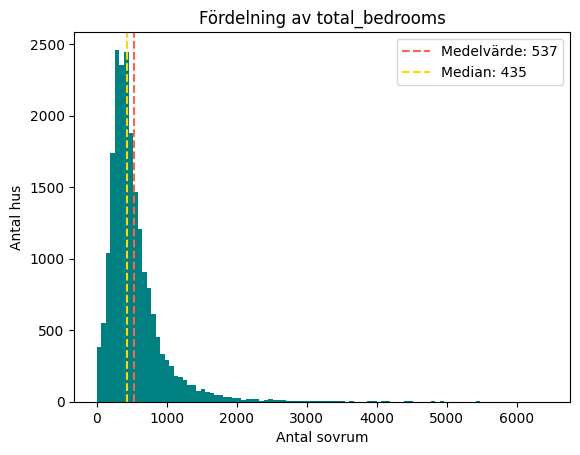

In [52]:
plt.hist(df['total_bedrooms'], bins=100, color='teal') 
plt.axvline(df['total_bedrooms'].mean(), color='tomato', linestyle='--', label=f'Medelvärde: {df["total_bedrooms"].mean():.0f}')
plt.axvline(df['total_bedrooms'].median(), color='gold', linestyle='--', label=f'Median: {df["total_bedrooms"].median():.0f}')
plt.title('Fördelning av total_bedrooms')
plt.xlabel('Antal sovrum')
plt.ylabel('Antal hus')
plt.legend()
plt.show()

In [49]:
#ersätter missing data med medianen
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [55]:
#df.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64

In [94]:
#Skapar nya variabler 
df['rooms_per_household'] = df['total_rooms'] / df['households'] #Rum per hushåll
df['bedrooms_ratio'] = df['total_bedrooms'] / df['total_rooms'] #Sovrum per hushåll
df['population_per_household'] = df['population'] / df['households'] #Personer per hushåll

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20433 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  str    
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20433 non-null  float64
 12  population_per_household  20640 non-null  float64
dtypes: float64(12), str(1)
memory usage: 2.0 MB


## Deskriptiv statistik

In [61]:
#Få en snabb överblick över statistiken
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909,5.429000,0.213794,3.070655
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874,2.474173,0.065248,10.386050
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.037151,0.692308
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000,4.440716,0.175225,2.429741
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,5.229129,0.203159,2.818116
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000,6.052381,0.240126,3.282261
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,2.824675,1243.333333


Värderna är nog inte alla numeriskt kontunerliga, 
utan misstanke är att det finns äldre hus än 52 år och högre hus inkomst per median än 500001 US dollar. Dvs de är ändliga och har blivit kapade. 
Inkomst låter ej rimlig så är nog i en felaktig skala.  Tror det saknas två nollor så medelevärde ska vara 38 700 us dollar. Timlön skulle kunna vara rimligt, definiering är väldigt viktigt för korrekta tolkningar. 
Ser att vissa max nummer sticker iväg tillexempel vid "total antal rum", får kolla närmare då jag visuliserar. 
Har i åtanke att det är enklare att se då vi gör boxplot, histogram och andra visulariseringar. 

## Visulariseringar och fördelningar

In [37]:
#Vill veta mer om vår kategorsika kolumn
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

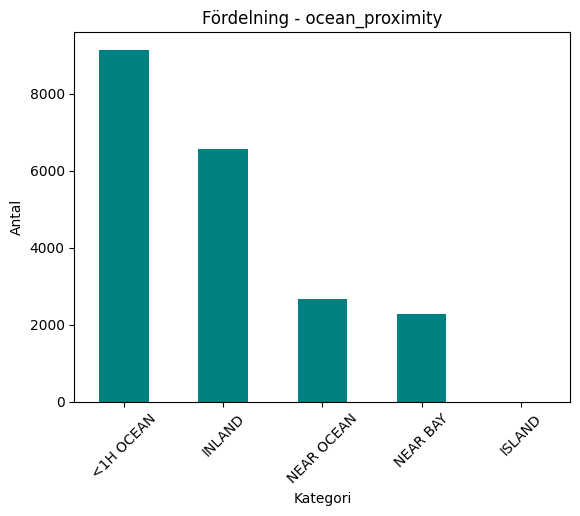

In [15]:
df['ocean_proximity'].value_counts().plot(kind='bar', color='teal')
plt.title('Fördelning - ocean_proximity')
plt.xlabel('Kategori')
plt.ylabel('Antal')
plt.xticks(rotation=45)
plt.show()
#Att vi bara har fem observationer på öar, "ISLAND" kan sälla till det för vår ML model sen och resultat bör tolkas med stor försiktighet. 
#Kan man slå ihop den med en annan variabel? På öar bor det generellt sätt mindre männsikor och det är kanske något som ska fångas upp?

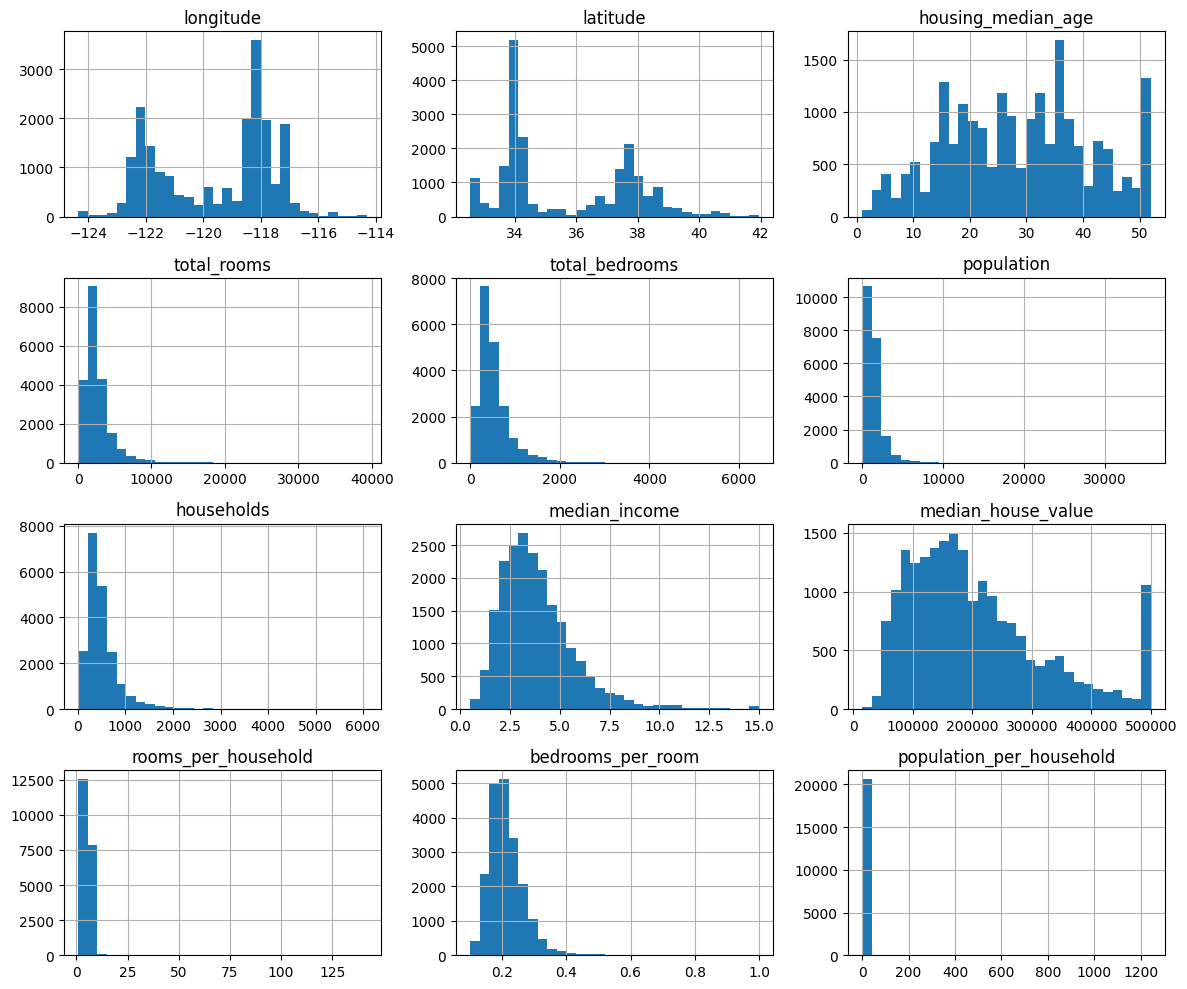

In [92]:
#Vi kikar på fördelningen lite grovt i histogram. Flera är positivt skeva. 
df.hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

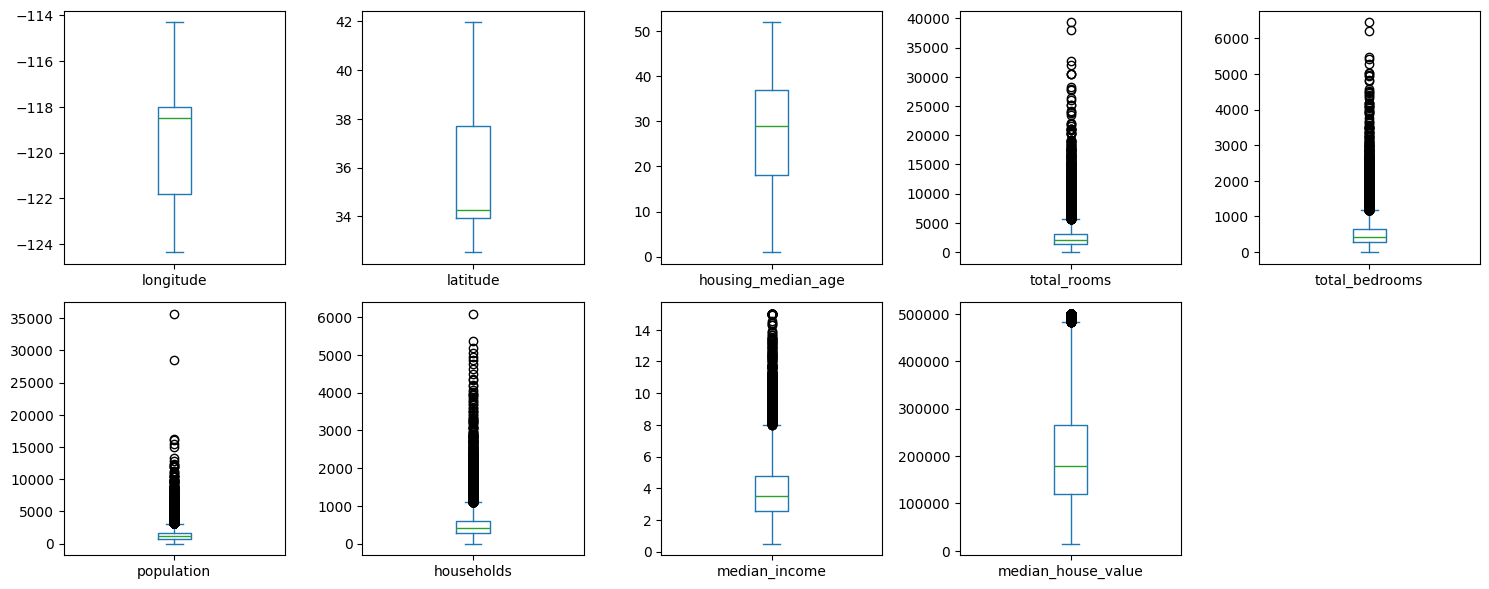

In [87]:
#Gör även induviduella boxplots för att få en överskaplig bild i kombination med min describe. 
#Vi kan observera att det kan förekomma outliers men viktigt med domän kunskap innan vi går in i datan. 
#Kanske är det ingen outlier, bara ett för litet dataset. Vi kan inte bara gå in och "snygga" till i vår data för att vi vill ha ett visst resultat.
df.plot(kind='box', figsize=(15, 6), subplots=True, layout=(2,5))
plt.tight_layout()
plt.show()

Boxplot beskriver samma sak som när vi tog ut den deskreptiva statistiken i describe. Lådan är Q1-Q3 där den gröna linjen är medianen. Morrhåren är max och min och outliers defineras enligt denna model, 1.5 × IQR från lådans kanter.

In [100]:
df_num = df.select_dtypes(include='number')

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
undre = Q1 - 1.5 * IQR
övre  = Q3 + 1.5 * IQR

outliers = ((df_num < undre) | (df_num > övre))

print(outliers.sum())

longitude                      0
latitude                       0
housing_median_age             0
households                  1220
median_income                681
median_house_value          1071
rooms_per_household          511
bedrooms_per_room            582
population_per_household     711
bedrooms_ratio               582
dtype: int64


In [96]:
Median_house_value har 1071 outliers, men det behöver inte säga så mycket. Kanske har vi ett för litet dataset, kanske är det kapningen som spökar.

SyntaxError: invalid syntax (238575652.py, line 1)

## Korrelationer och samband

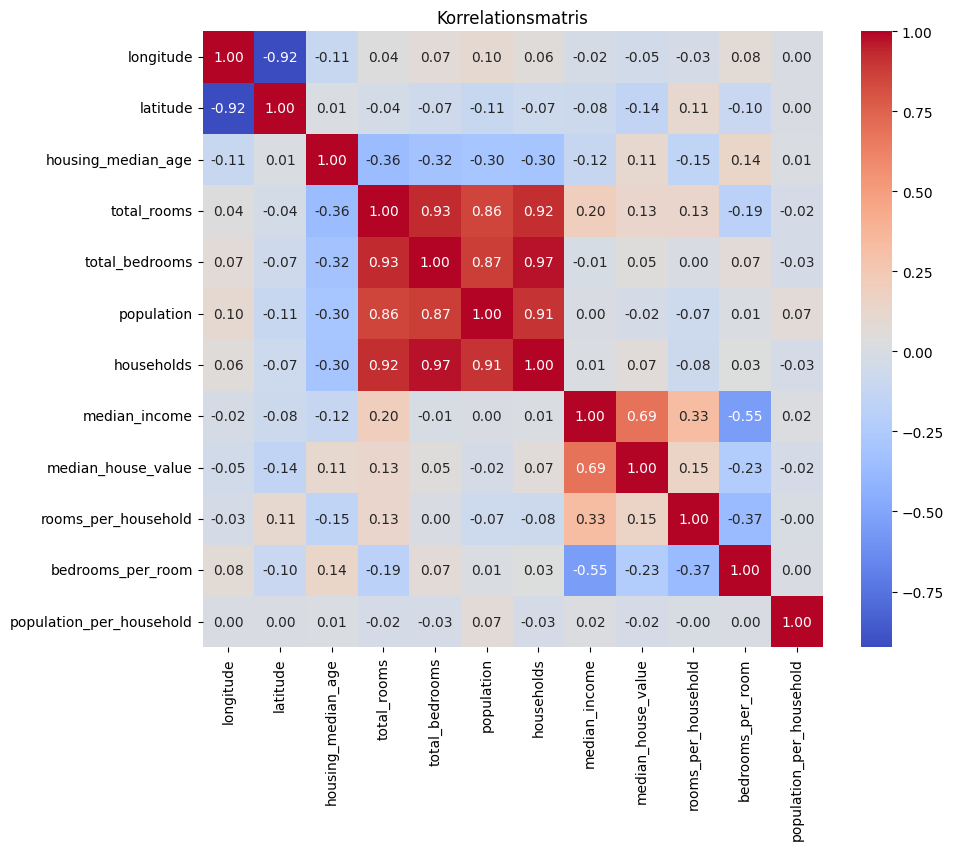

In [64]:
# -1 och 1 perfekt linjär korrelation. 0-inget linjärt samband. 
# Korrelation är inte kausalitet
# Observera om det finns multikollinearitet och givetvis att datan är insamlad på ett bra sätt för att minska chansen för skenbara samband.
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korrelationsmatris')
plt.show()

Median_house_value korrelerar starkt-måttligt med median_income. (R=0.69). Vilket känns rimlig, att inkomst påverkar hur dyrt hus man har råd att bo i.
Den varabeln har störst förklaringskraft. 
Våra nya variabler får utslag på multikollineariotet med de gamla variablerna. Om vi skulle använda detta för en model sen så skulle jag ta bort de gamla varaiblerna. 
Bedrooms_per_room (R=-0.23), rooms_per_housholde (R=0.15), housing_median_age (R=-0.11) har ett visst samband

median_income är den klart starkaste prediktorn (R=0.69). Sambandet är måttligt till starkt positivt, vilket hängere ihop med att högre inkomster 
hänger ihop med högre huspriser. Hus med hög andel sovrum verkar ha lägre värde, det kan bero på att dessa hus har mindre rum till annat eller
socioekonomiska faktorer som fångas upp, (R=-0.23). Däremot så har rum per hus en positiv korrelation men är svagt med (R=0.15).

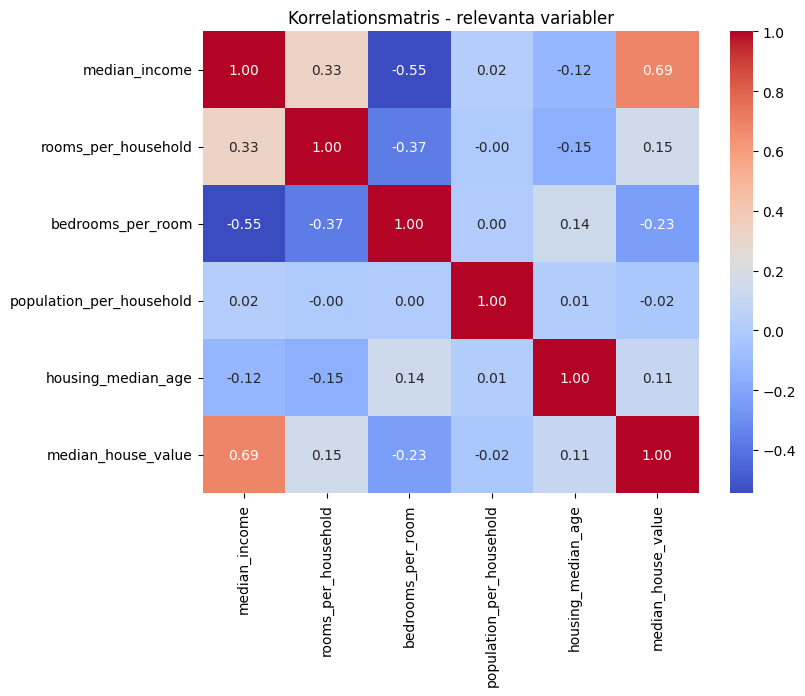

Population_per_household påverkar verkar inte ha någon förklaringsgrad på husets värde, vilket känns rimligt. 
Dyrare hus kan ha både stora familjer i stora vilor och singlar kan ha lyxlägenheter/hus.



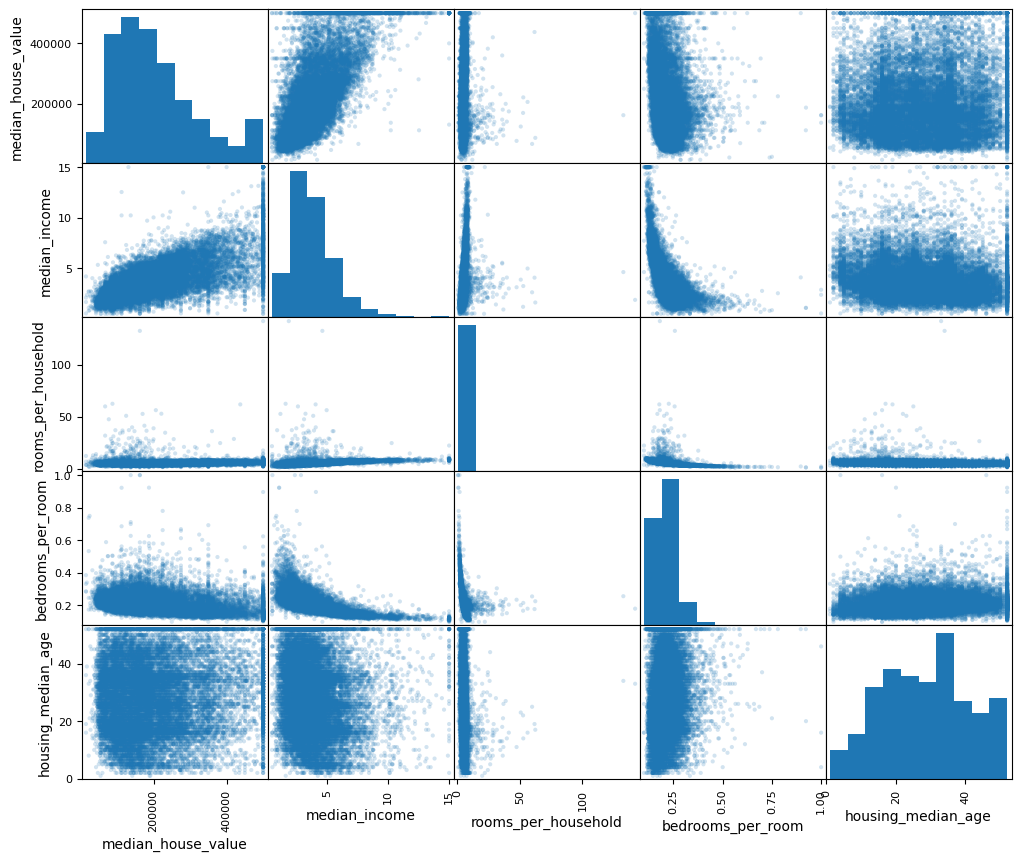

In [39]:
from pandas.plotting import scatter_matrix

scatter_matrix(df[['median_house_value', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'housing_median_age']], 
               figsize=(12,10), alpha=0.2)
plt.show()

#Korrelations matriser på de som korrelerar starkast med median_house_value men alla samband behöver ju inte vara linjära

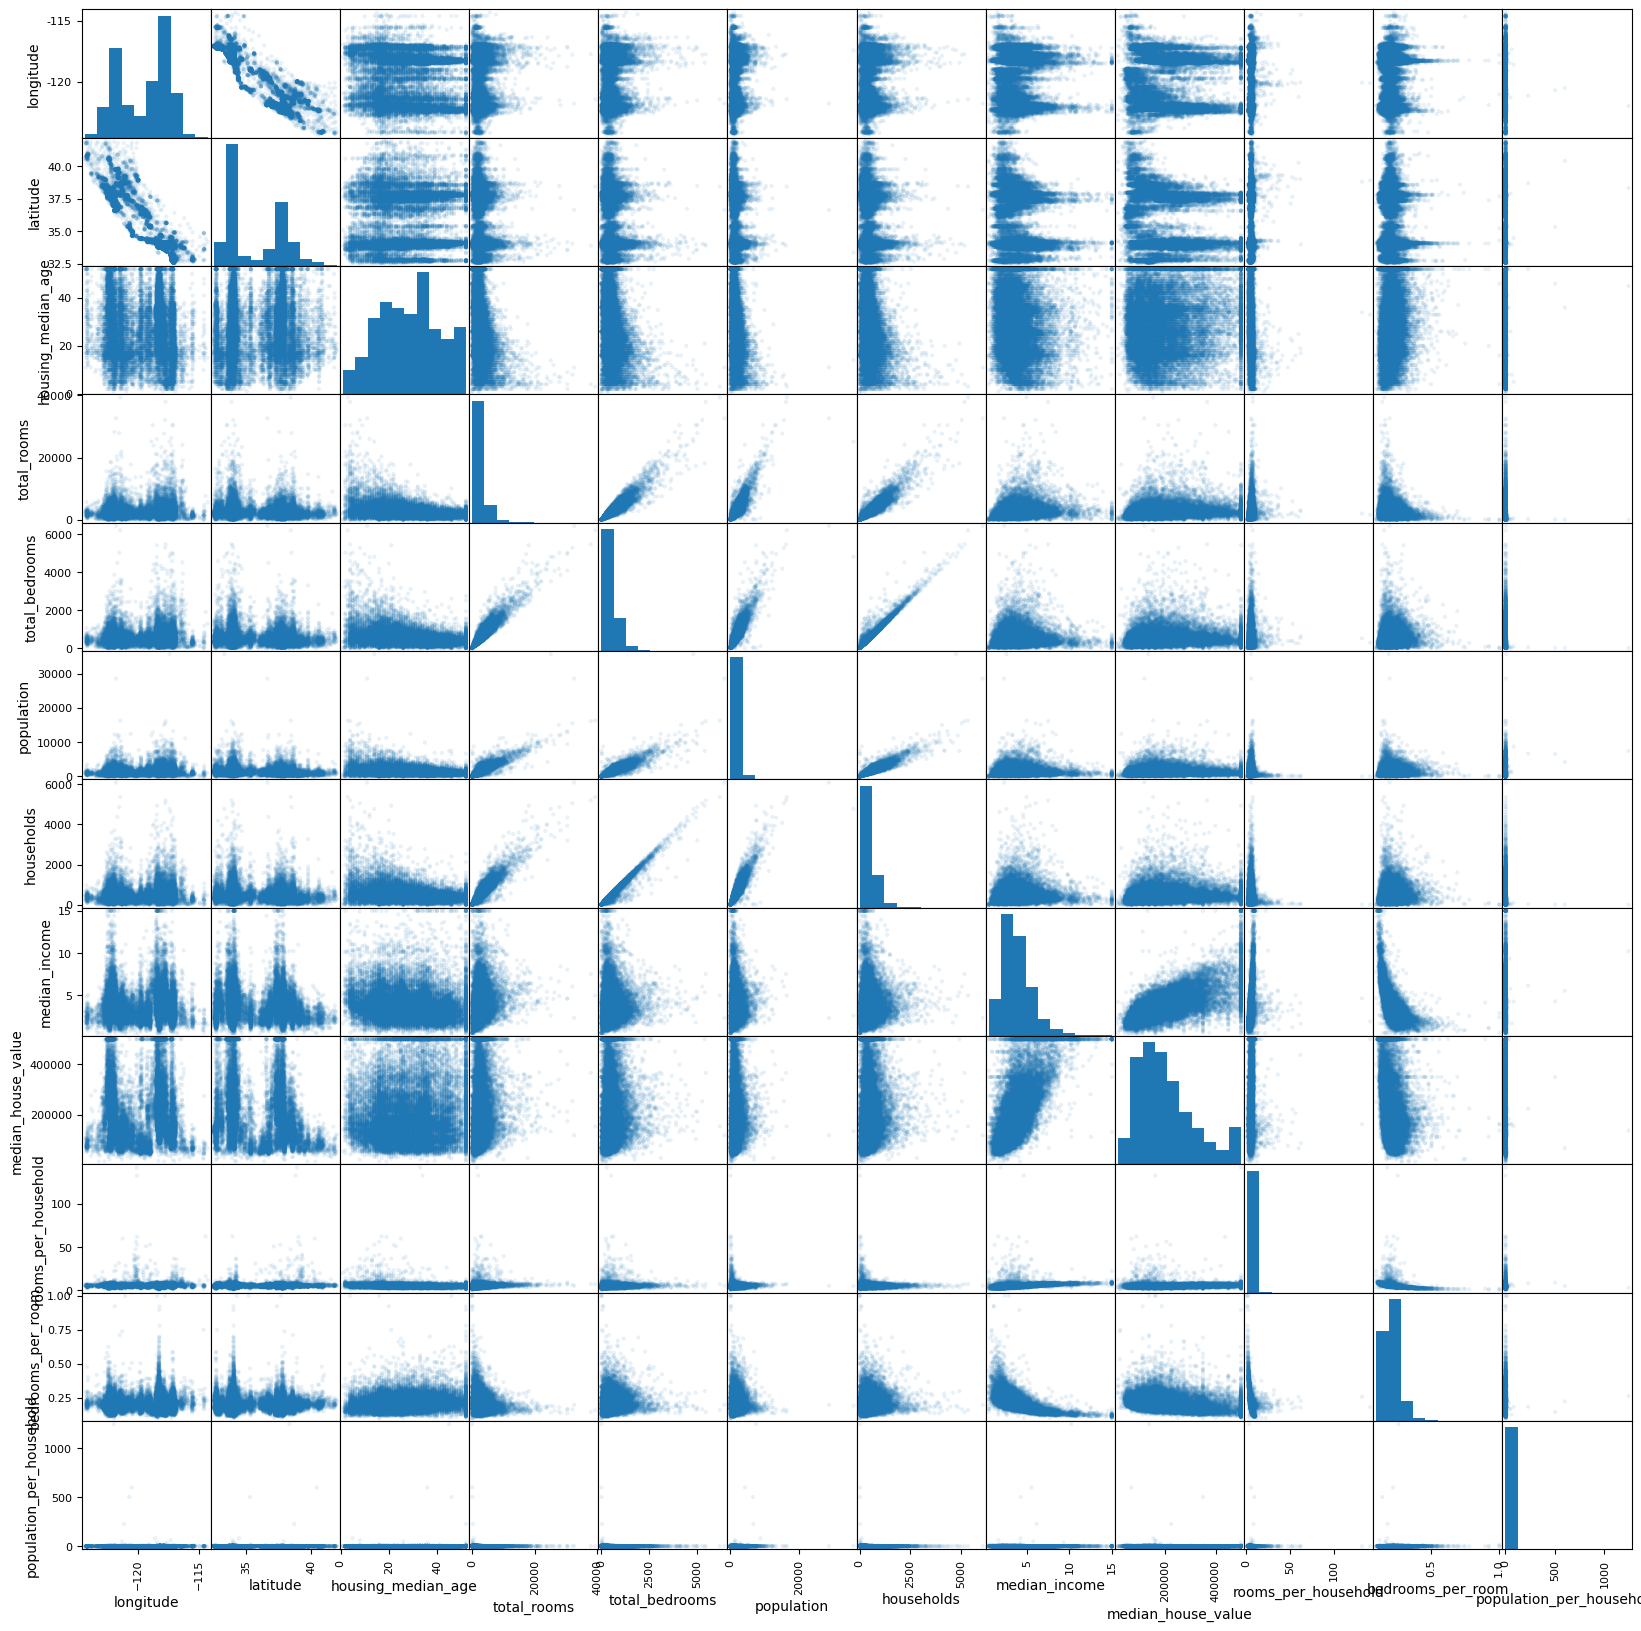

In [43]:
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(20, 20), alpha=0.1)
plt.show()
#Eftersom inte alla samband behöver vara linjära 

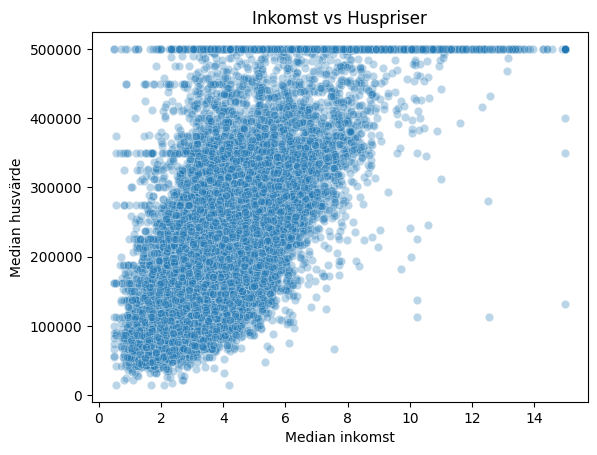

In [22]:
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.3)
plt.title('Inkomst vs Huspriser')
plt.xlabel('Median inkomst')
plt.ylabel('Median husvärde')
plt.show()
#Vi ser att det skett capping vid inkomster, verkliga toppvärdet är okänt. 
# Ett linjärt samband men det finns stor spridning så finns mycket som inte median_income ensamt kan svara på. 

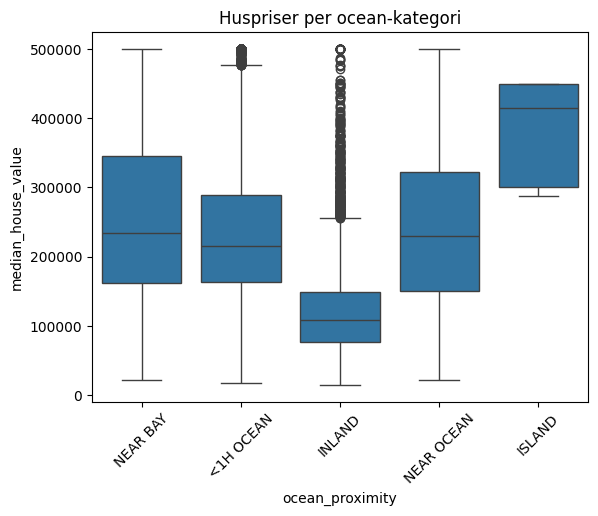

In [23]:
#Gör antagandet att läget  till havet kan påverka priset, så testar hur det ser ut i en boxplot.
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df)
plt.title('Huspriser per ocean-kategori')
plt.xticks(rotation=45)
plt.show()
#Island få observationer, utala sig med försiktighet kring
#Inland har lägst huspriser men också endel observationer som är utanför percentilerna
#ocean_proximity är en intressant variabel för huspriser. Bör kodas om till dummies innan ML model.
#Det finns en kapning på 500 001. Har ej domän kunskap så vet inte vad outliersna beror på, kanske är de nära en stad eller fint område som inte fångas upp i vår data/modell. 

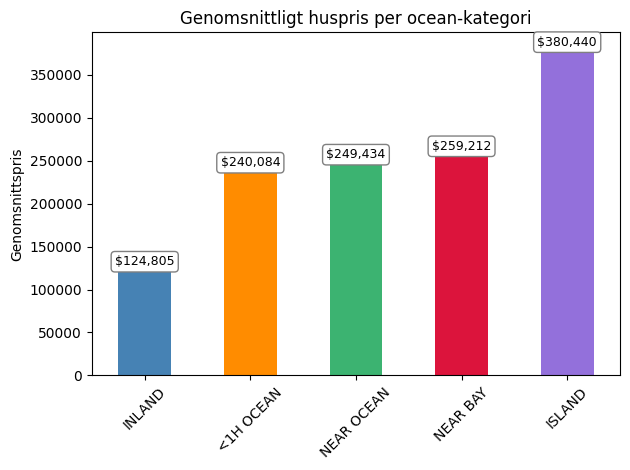

In [84]:
import matplotlib.pyplot as plt

medel = df.groupby('ocean_proximity')['median_house_value'].mean().sort_values()

colors = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson', 'mediumpurple']

ax = medel.plot(kind='bar', color=colors)
plt.title('Genomsnittligt huspris per ocean-kategori')
plt.xlabel('')
plt.ylabel('Genomsnittspris')
plt.xticks(rotation=45)

for i, (kategori, värde) in enumerate(medel.items()):
    ax.annotate(f'${värde:,.0f}',
                xy=(i, värde),
                ha='center', va='bottom',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()

#Inland sticker ut. Island väljer jag att inte tolka pga det lilla urval.

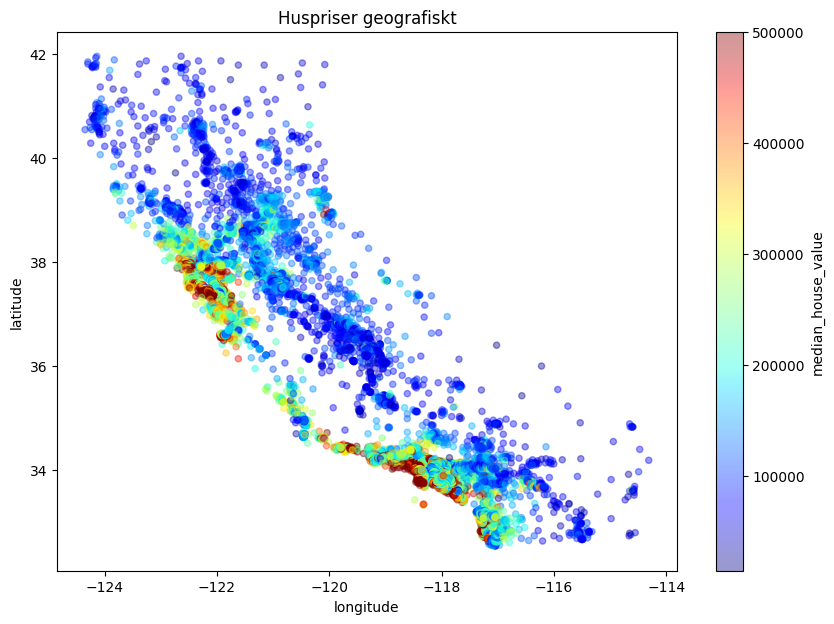

In [25]:
df.plot(kind='scatter', x='longitude', y='latitude',
        alpha=0.4, c='median_house_value',
        cmap='jet', figsize=(10,7))
plt.title('Huspriser geografiskt')
plt.show()

In [70]:
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[36.7, -119.4], zoom_start=6, tiles='CartoDB positron')

heat_data = df[['latitude', 'longitude', 'median_house_value']].values.tolist()
HeatMap(heat_data, min_opacity=0.2, radius=15, blur=20,
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 1: 'red'}).add_to(m)

# 10 dyraste - röda markers
for _, row in df.nlargest(10, 'median_house_value').iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8, color='red', fill=True, fill_opacity=0.9,
        popup=f"💰 {row['median_house_value']:,.0f} USD | {row['ocean_proximity']}"
    ).add_to(m)

# 10 billigaste - blå markers
for _, row in df.nsmallest(10, 'median_house_value').iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=8, color='blue', fill=True, fill_opacity=0.9,
        popup=f"🏚️ {row['median_house_value']:,.0f} USD | {row['ocean_proximity']}"
    ).add_to(m)

# Titel + legend
legend_html = '''
<div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
z-index:1000; background:white; padding:12px 20px; border-radius:8px;
box-shadow:2px 2px 6px rgba(0,0,0,0.3); font-family:Arial; text-align:center">
    <b>🏠 Kalifornien — Huspriser per område</b><br><br>
    <span style="color:red">● Topp 10 dyraste</span> &nbsp;|&nbsp;
    <span style="color:blue">● Topp 10 billigaste</span><br><br>
    <span style="background:linear-gradient(to right, blue, lime, orange, red);
    width:150px; height:12px; display:inline-block; border-radius:4px"></span><br>
    <small>Lågt pris → Högt pris</small>
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))

m

In [71]:
print("10 DYRASTE:")
print(df.nlargest(10, 'median_house_value')[['latitude', 'longitude', 'median_house_value', 'ocean_proximity']])

print("\n10 BILLIGASTE:")
print(df.nsmallest(10, 'median_house_value')[['latitude', 'longitude', 'median_house_value', 'ocean_proximity']])

# De 10 "dyraste" har alla värdet 500001 - bekräftar capping i datasetet
# Verkliga toppvärden okända, viktigt att hantera innan ML-modell
# De billigaste ligger nästan uteslutande INLAND

10 DYRASTE:
     latitude  longitude  median_house_value ocean_proximity
89      37.80    -122.27            500001.0        NEAR BAY
459     37.87    -122.25            500001.0        NEAR BAY
493     37.86    -122.24            500001.0        NEAR BAY
494     37.85    -122.24            500001.0        NEAR BAY
509     37.83    -122.23            500001.0        NEAR BAY
510     37.82    -122.22            500001.0        NEAR BAY
511     37.82    -122.22            500001.0        NEAR BAY
512     37.82    -122.23            500001.0        NEAR BAY
514     37.82    -122.23            500001.0        NEAR BAY
517     37.82    -122.23            500001.0        NEAR BAY

10 BILLIGASTE:
       latitude  longitude  median_house_value ocean_proximity
2521      39.71    -122.74             14999.0          INLAND
2799      36.40    -117.02             14999.0          INLAND
9188      34.24    -117.86             14999.0          INLAND
19802     40.31    -123.17             14999.0   

Analys av läge: Eftersom de har kapat i vårt data så kan vi inte se vart de absolut dyrast bostäderna ligger.Vi kan se att det är dyrt runt St Monica och San Francisco, men eftersom det är kvartersbaserat kan billigt och dyrt ligga relativt nära varandra. 
Vi kan dock uttala oss om att det ofta är dyrare bostäder om området är nära havet och hushållet har en högre medianinkomst

Jag tyckte att det är konstigt med så högt antal rum per hushåll i vår rå data, så vill kika närmare på det.

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: rooms_per_household, dtype: float64

Antal hus med över 10 rum per hushåll: 226
Max värde: 142 rum per hushåll


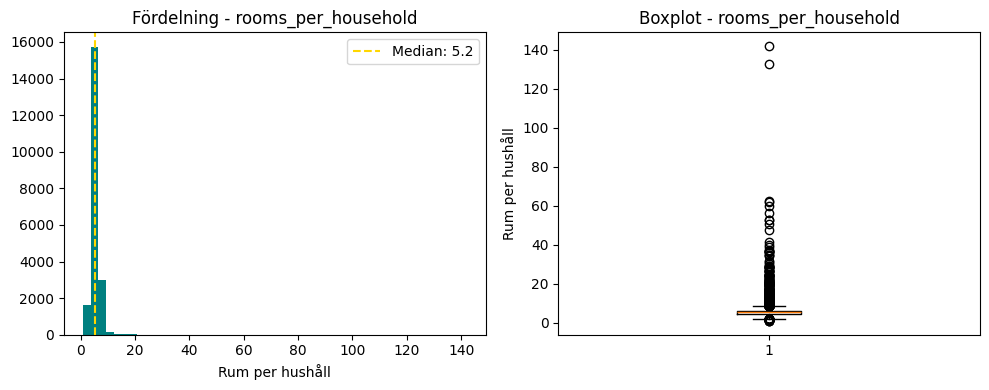

In [73]:
print(df['rooms_per_household'].describe())
print(f"\nAntal hus med över 10 rum per hushåll: {(df['rooms_per_household'] > 10).sum()}")
print(f"Max värde: {df['rooms_per_household'].max():.0f} rum per hushåll")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['rooms_per_household'], bins=50, color='teal')
plt.axvline(df['rooms_per_household'].median(), color='gold', linestyle='--', label=f'Median: {df["rooms_per_household"].median():.1f}')
plt.title('Fördelning - rooms_per_household')
plt.xlabel('Rum per hushåll')
plt.legend()

plt.subplot(1,2,2)
plt.boxplot(df['rooms_per_household'])
plt.title('Boxplot - rooms_per_household')
plt.ylabel('Rum per hushåll')

plt.tight_layout()
plt.show()

In [74]:
#Tror 142 rum måste vara en outlier och något hotell eller liknande har kommit med. Fast med det sagt så kan det ju finnas slott eller liknande
#så utan domän kunskap kan jag inte bara plocka bort. Det är ca en procent som faller innanför ramarna. 
procent = (226 / len(df)) * 100
print(f"Andel outliers: {procent:.2f}%")

Andel outliers: 1.09%


In [97]:
#För att undvika mulitikollinearitet och hålla tungan rätt i munnen så väljer jag att droppa de gamla  variablerna iaf jag  fortsätter att använda detta dataset. 
##(Skapar nya variabler 
#df['rooms_per_household'] = df['total_rooms'] / df['households'] #Rum per hushåll
#df['bedrooms_ratio'] = df['total_bedrooms'] / df['total_rooms'] #Sovrum per hushåll
#df['population_per_household'] = df['population'] / df['households'] #Personer per hushåll)

df_original = df.copy()

df = df.drop(columns=['total_rooms', 'total_bedrooms', 'population'])

In [99]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   households                20640 non-null  float64
 4   median_income             20640 non-null  float64
 5   median_house_value        20640 non-null  float64
 6   ocean_proximity           20640 non-null  str    
 7   rooms_per_household       20640 non-null  float64
 8   bedrooms_per_room         20433 non-null  float64
 9   population_per_household  20640 non-null  float64
 10  bedrooms_ratio            20433 non-null  float64
dtypes: float64(10), str(1)
memory usage: 1.7 MB


## Insikter och sammanfattning

Vi arbetar med ett äldre dataset, så får helt enkelt lita på att det är insamlat på ett statistiskt tillförlitligt sätt. 
Vi hade 20 640 observationer och 10 variabler att arbeta med för vår EDA. Median_house_value har problem då de har valt att kapa max värdet och inte ha det kontunerligt numeriskt. De kanske gjorde det för att de ville snygga till i sin data och på så sätt få bort extrema värden. Probelmet blir att i dessa "extrema" värden kan det ha legat en historia och värdefulla insikter. Vi underskattar antagligen priserna i rika områden. Om max ålder på bostäder är 52 år vet jag inte eller om det också var en kapning, men just den variabeln berättade inte så mycket men frågan så som vi har datan just nu.
Vi jobbade även mycket med median siffor vilket kan maskera spridningar som vi inte fångar upp, det är givetvis mer jobb med rådata men vi kan få mycket bättre insikter och kontrollera allt nogrannare med rådata istället för data som redan gjorts om. Varför vi saknade data vet jag inte och varför vi hade lite galna siffror då det kom till rum per hushåll till exempel.
Jag tror den här EDA visar på att det är sällan man får jobba med perfekt fullständig data som är precis som man vill ha det, utan det kan vara precis som i det här datasetet och sakna värden. 

Slutligen. Vi kan utifrån den här datan säga att områden där hushålen har högre median inkomst och där husen ligger vid havet har ett högre uppskattat pris. 
i kan även säga att de med lägre median inkomst som bor inland att deras mediana huspriser är lägst. Vi hade en korrelation på R=0.15 för rum, vilket kan kännas logiskt om man tänker att fler rum hänger ihop med ett större hus, men sambandet är ändock relativt svagt då man kan ha ett hus med många rum även i fattigare områden. Äldre median ålder på husen hade en (R=0.11) vilket är låg förklaringsgrad då äldre hus kan vara slitna men de kan också vara värda mer om de ligger i en attraktiv stadsdel. 

Vi valde att inte kapa i outliers då jag saknar domän kunskap, däremot räknade python ut att dessa värden låg utanför den undre gräns: Q1 − 1.5 × IQR
övre gräns: Q3 + 1.5 × IQR. 
households                  1220
median_income                681
median_house_value          1071
rooms_per_household          511
bedrooms_per_room            582
population_per_household     711
bedrooms_ratio               582


Slut ord, detta är bara början på en EDA och att det är här mycket arbete kommer läggas då vi vill ha bra data kvalite och på så sätt kunna göra bra ML modeller. 

        
